# Resume/CV Filtering System

## Problem Statement:

Recruiters often have to manually go through **100+** resumes, many of which might be irrelevant to the job description. 
- This is time-consuming, inconsistent, and inefficient. 

Goal of this project : Automate the initial screening process by filtering out resumes that are clearly not aligned with the job role. 
- Identifying the best resume is subjective and often varies across hiring managers & Industry.
- A common ground is the need to **reject clearly non-matching resumes**, making the screening process faster and more efficient.

## Objective:

Build a resume filtering system that:
* Accepts a job description and a folder of resumes (PDFs)
* Uses two different similarity models to compare each resume with the JD
* Flags resumes that are irrelevant or out of scope
* Provides both quantitative scores and visual insights

⚠️ Note: The aim is **not** to recommend the best candidate, but to automate the first-level filtering of obviously non-matching resumes.

__Notebook Setup__

In [1]:
# !pip install pymupdf
# !pip install gensim

In [22]:
# !pip install wordcloud

In [2]:
# !pip install sentence-transformers

In [77]:
# !pip install matplotlib-venn

In [2]:
import fitz  # PyMuPDF
import os
import nltk
nltk.download('punkt')      # Tokenizer
nltk.download('stopwords')  # Common words like "the", "and"
nltk.download('wordnet')    # For lemmatization

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer, util

import warnings
warnings.filterwarnings('ignore')

import pandas as pd

import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import seaborn as sns

import re
import string
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from matplotlib_venn import venn2
from matplotlib_venn import venn3

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [3]:
base_path = r"C:\Users\User\Desktop\Projects\ResumeFilter-main"

# Initial Setup & Sample check

Helper functions:
- Extract raw text from resume and job description PDFs
- Preprocess the extracted text by cleaning and normalizing it

**Extracting Text from PDF File**

In [6]:
def extract_text_from_pdf(pdf_path):
    text = ""
    with fitz.open(pdf_path) as doc:
        for page in doc:
            text += page.get_text()
    return text

**Preprocessing Text obtained from the PDF**

In [7]:
# def preprocess_text(text):
#     text = text.lower()
#     text = re.sub(r'\S+@\S+', '', text)        # Remove emails
#     text = re.sub(r'http\S+|www\S+', '', text) # Remove URLs
#     text = re.sub(r'\d+', '', text)            # Remove digits
#     text = re.sub(r'[^\w\s]', '', text)        # Remove punctuation

#     tokens = word_tokenize(text)
#     stop_words = set(stopwords.words('english'))
#     tokens = [word for word in tokens if word not in stop_words]

#     lemmatizer = WordNetLemmatizer()
#     lemmatized = [lemmatizer.lemmatize(word) for word in tokens]

#     return ' '.join(lemmatized)


In [8]:
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove emails and URLs
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove digits and punctuation
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize and remove stopwords
    tokens = text.split()
    tokens = [word for word in tokens if word not in ENGLISH_STOP_WORDS]

    # Optionally: simple lemmatization (skip for now if you want full speed)
    return ' '.join(tokens)


## Sample file checking

**Sample 1 DA**

In [9]:
Sample_1_DA_CV_Text = extract_text_from_pdf(os.path.join(base_path, "Data Analyst - CVs", "DA_1.pdf"))

In [10]:
Sample_1_DA_CV_Text

'Justine Debowski\nSenior Insurance Data Analyst\nProven senior insurance data analyst with 10+ years of experience leading\ncutting-edge teams and analyzing small and large data sets. As a Lead IDA, I\nspearheaded a highly skilled team that identified, recommended, and\nimplemented continuous improvements based on gathered data. I believe that\nmy experience in leading highly-effective teams and analyzing all types and\nscales of data makes me an excellent candidate for this role at BitBucket.\njustinedeb@email.com\n(123) 456-7890\nDenver, CO\ntwitter.com/just-deb\n\nWORK EXPERIENCE\nPie Insurance\nLead Insurance Data Analyst\nDenver, CO | 2019 - current\nProduced and delivered 100+ BI dashboards and reports\nMeasured and demonstrated organizational efficiencies with data\nanalysis and reporting\nWorked with 6 technical and business peers on development efforts,\nincluding designing, analyzing, assessing, and reporting\nManaged 100% of data management deliverables such as business nee

In [11]:
clean_resume_text_1 = preprocess_text(Sample_1_DA_CV_Text)
clean_resume_text_1

'justine debowski senior insurance data analyst proven senior insurance data analyst years experience leading cuttingedge teams analyzing small large data sets lead ida spearheaded highly skilled team identified recommended implemented continuous improvements based gathered data believe experience leading highlyeffective teams analyzing types scales data makes excellent candidate role bitbucket denver twittercomjustdeb work experience pie insurance lead insurance data analyst denver current produced delivered bi dashboards reports measured demonstrated organizational efficiencies data analysis reporting worked technical business peers development efforts including designing analyzing assessing reporting managed data management deliverables business need analysis highlevel data modeling techniques identified recommended implemented appropriate continuous improvement opportunities argo group data analyst denver identified analyzed interpreted trends patterns complex data sets used statis

**Sample 2 Non DA**

In [12]:
Sample_2_NonDA_CV_Text = extract_text_from_pdf(os.path.join(base_path, "Data Analyst - CVs", "Non_DA_1.pdf"))
clean_resume_text_2 = preprocess_text(Sample_2_NonDA_CV_Text)
clean_resume_text_2

'kristi laar registered nurse contact st avenue redmond wa communication received awards outstanding communication skills including recognition providing exceptional patient education counseling leadership received outstanding nursing student award time nursing school recognized contributions patient safety satisfaction current role education bellows college madison wi bachelors science nursing relevant coursework anatomy physiology pharmacology nursing ethics patient care management experience november xx–october xx registered nurse pediatrics wholeness healthcare december xx–november xx registered nurse general practice wholeness healthcare september xx–august xx registered nurse general practice tyler stein md proven track record delivering highquality care maintaining patient safety satisfaction references available request'

**JD - DA**

In [13]:
DA_JD_Text = extract_text_from_pdf(os.path.join(base_path, "Data Analyst - JD", "Data Analyst - JD.pdf"))

In [14]:
# DA_JD_Text

In [15]:
clean_jd = preprocess_text(DA_JD_Text)

In [16]:
clean_jd

'job title data analyst company insight analytics pvt location colombo sri lanka employment type fulltime experience level entry midlevel job description looking detailoriented analytical data analyst join dynamic team ideal candidate responsible collecting processing performing statistical analyses large datasets generate actionable business insights key responsibilities • gather clean interpret large volumes data multiple sources • develop reports dashboards visualizations using tools like power bi tableau • identify trends anomalies patterns influence business decisions • work closely business product teams define data needs insights • assist building predictive models datadriven strategies • maintain data quality integrity reporting processes required skills qualifications • bachelor’s degree statistics computer science mathematics economics related field • strong knowledge sql querying databases • proficiency excel data visualization tools power bi tableau • experience python r da

# Exploratory Data Analysis (EDA)

Helper functions:

- Common words between two set of texts
- Word cloud plot to visualize the common words
- Creating venn diagrams between two set of texts words

**Common words**

In [17]:
def get_common_words(text1, text2, top_n=20):
    # Tokenize
    words1 = text1.split()
    words2 = text2.split()

    # Count frequencies
    freq1 = Counter(words1)
    freq2 = Counter(words2)

    # Find common words
    common = set(freq1.keys()).intersection(set(freq2.keys()))
    common_freq = {word: freq1[word] + freq2[word] for word in common}

    # Sort by total freq (desc)
    common_sorted = dict(sorted(common_freq.items(), key=lambda x: x[1], reverse=True)[:top_n])
    return common_sorted, len(common)

**Word Cloud**

In [46]:
def plot_common_words(common_dict, title):
    wc = WordCloud(width=500, height=200, background_color='white').generate_from_frequencies(common_dict)
    plt.figure(figsize=(8, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()

## Common Words Analysis

### What's common between DA CV & DA JD

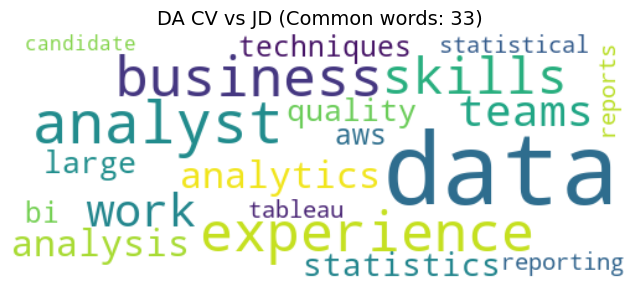

✅ Common words in DA CV vs JD: 33


In [47]:
# DA CV vs JD
common_da, count_da = get_common_words(clean_resume_text_1, clean_jd)
plot_common_words(common_da, f"DA CV vs JD (Common words: {count_da})")
# print(f" Common words in DA CV vs JD: {count_da}")

### What's common between Non DA CV & DA JD

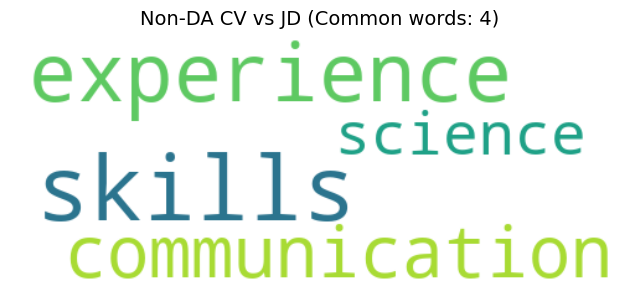

❌ Common words in Non-DA CV vs JD: 4


In [48]:
# Non-DA CV vs JD
common_nonda, count_nonda = get_common_words(clean_resume_text_2, clean_jd)
plot_common_words(common_nonda, f"Non-DA CV vs JD (Common words: {count_nonda})")
# print(f" Common words in Non-DA CV vs JD: {count_nonda}")

## Word Overlaps : Venn Diagrams

In [21]:
def plot_venn(text1, text2, label1="Text 1", label2="Text 2", title=""):
    set1 = set(text1.split())
    set2 = set(text2.split())
    
    plt.figure(figsize=(6, 6))
    venn = venn2([set1, set2], set_labels=(label1, label2))
    plt.title(title)
    plt.show()
    
    common_count = len(set1.intersection(set2))
    print(f"No of common words between {label1} and {label2}: {common_count}")

### DA CV vs JD

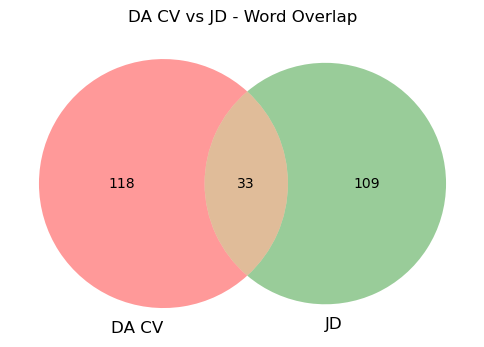

🔁 Number of common words between DA CV and JD: 33


In [22]:
# DA CV vs JD
plot_venn(clean_resume_text_1, clean_jd, label1="DA CV", label2="JD", title="DA CV vs JD - Word Overlap")

### Non DA CV vs JD

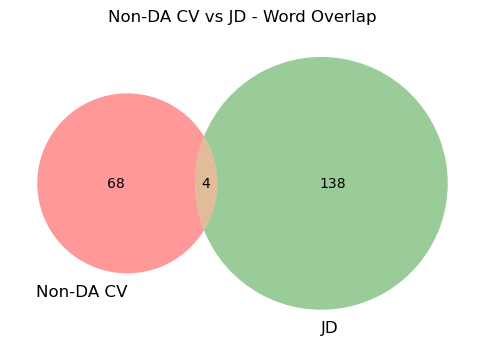

🔁 Number of common words between Non-DA CV and JD: 4


In [23]:
# Non-DA CV vs JD
plot_venn(clean_resume_text_2, clean_jd, label1="Non-DA CV", label2="JD", title="Non-DA CV vs JD - Word Overlap")

### DA CV vs Non–DA CV vs JD

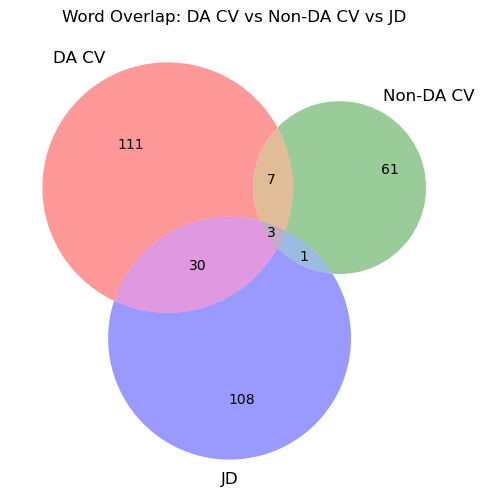

✅ DA CV ∩ JD: 33 words
❌ Non-DA CV ∩ JD: 4 words
🟡 DA CV ∩ Non-DA CV: 10 words
🔁 Common to all three: 3 words


In [24]:
# Token sets
da_cv_words = set(clean_resume_text_1.split())
non_da_cv_words = set(clean_resume_text_2.split())
jd_words = set(clean_jd.split())

# Intersections
common_da_jd = da_cv_words.intersection(jd_words)
common_nonda_jd = non_da_cv_words.intersection(jd_words)
common_da_nonda = da_cv_words.intersection(non_da_cv_words)
common_all_three = da_cv_words & non_da_cv_words & jd_words

# Plot Venn Diagram
plt.figure(figsize=(6, 6))
venn3([da_cv_words, non_da_cv_words, jd_words], 
      set_labels=("DA CV", "Non-DA CV", "JD"))
plt.title("Word Overlap: DA CV vs Non-DA CV vs JD")
plt.show()

# Print Insights
print(f" DA CV ∩ JD: {len(common_da_jd)} words")
print(f" Non-DA CV ∩ JD: {len(common_nonda_jd)} words")
print(f" DA CV ∩ Non-DA CV: {len(common_da_nonda)} words")
print(f" Common to all three: {len(common_all_three)} words")

**Only between Non DA CV & JD**

In [25]:
common_nonda_jd - common_all_three #1

{'communication'}

**Only between DA & Non DA CV**

In [26]:
common_da_nonda - common_all_three #7

{'college',
 'current',
 'education',
 'including',
 'management',
 'proven',
 'role'}

From the textual comparisons:

- The **Data Analyst resume shares over 30 meaningful words** with the job description, including key terms like `python`, `sql`, and `analytics`, strongly supporting its relevance to the role.
- The **Non–Data Analyst resume overlaps with the JD on only 4 generic words**: `skills`, `experience`, `science`, and `communication` all of which are commonly found in any resume, regardless of domain.
- The **two resumes (DA and Non–DA)** share generic terms like `education`, `experience`, `management`, and `skills`, highlighting words typically used across resumes.
- Only **3 words are common across all three texts**: `skills`, `experience`, and `science` again, common resume vocabulary.

These findings validate our modeling goal: to filter out resumes that only contain **surface-level similarity**, while retaining those that align with the **domain-specific language** found in the JD.



# Model Building and Resume Scoring

## Model 1 : TF IDF Vectorizer

**Comparing Resume Text and Job Description using TfidfVectorizer**

In [29]:
def calculate_tfidf_similarity(text1, text2):
    texts = [text1, text2]
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
    X = vectorizer.fit_transform(texts)
    sim = cosine_similarity(X[0:1], X[1:2])[0][0]
    return sim

`calculate_tfidf_similarity()` that compares any two pieces of text:

- It uses **TF-IDF (Term Frequency–Inverse Document Frequency)** to convert both texts into numeric vectors.
- The `ngram_range=(1, 2)` allows it to capture not just single words but also common word pairs (like `data analyst`, `machine learning`).
- Preprocessed PDF text are used as input.
- Once vectorized, we measure the **cosine similarity** between the two texts, a value between 0 and 1 that tells us how close they are.

*Higher the value → more overlap in important words.*


In [30]:
#DA
similarity_score_1 = calculate_tfidf_similarity(clean_resume_text_1, clean_jd)
print(f"Similarity Score for DA CV: {similarity_score_1:.2f}")

Similarity Score for DA CV: 0.28


In [31]:
#NonDA
similarity_score_2 = calculate_tfidf_similarity(clean_resume_text_2, clean_jd)
print(f"Similarity Score for Non DA CV: {similarity_score_2:.2f}")

Similarity Score for Non DA CV: 0.01


*These scores suggest that the Data Analyst CV shares a decent amount of vocabulary with the JD, while the non-relevant resume has almost no overlap.*

**Limitations of TF-IDF**

- It only looks at the **exact words** present. So if one resume says `analyzing data` and another says `data analysis`, TF-IDF may treat them differently.
- It doesn’t understand **context or meaning**. For example, the words `python`, `SQL`, and `analytics` may appear in unrelated contexts.

In our case, we observe:
- The DA CV gets a moderate score, which makes sense because it shares relevant technical terms.
- The Non–DA CV scores close to zero, meaning it's clearly irrelevant.

## Model 2 : Sentence Transformer

**Comparing Resume Text and Job Description using Sentence Transformer**

In [5]:
model = SentenceTransformer('all-MiniLM-L6-v2')  # Fast and lightweight

In [32]:
def calculate_semantic_similarity(text1, text2):
    embeddings = model.encode([text1, text2])
    similarity = util.cos_sim(embeddings[0], embeddings[1])
    return float(similarity)

`calculate_semantic_similarity()` that compares two pieces of text:

**sentence transformer** model called `all-MiniLM-L6-v2` to convert both the resume and job description into numeric vectors (called embeddings), and then calculate how close they are using cosine similarity.

Trained to understand **context and semantics** not just raw words

In [33]:
#DA
semantic_score_1 = calculate_semantic_similarity(Sample_1_DA_CV_Text, DA_JD_Text)
print(f"Similarity Score for DA CV: {semantic_score_1:.2f}")

Similarity Score for DA CV: 0.60


In [34]:
#Non DA
semantic_score_2 = calculate_semantic_similarity(Sample_2_NonDA_CV_Text, DA_JD_Text)
print(f"Similarity Score for Non DA CV: {semantic_score_2:.2f}")

Similarity Score for Non DA CV: 0.28


*Even though both scores are higher than in the TF-IDF model, we clearly see that the DA CV has much better alignment in meaning with the job description.*

# Scoring Multiple Resumes

[View Resume Collection](https://drive.google.com/drive/folders/13RyAwIznm0r7LEavOxYH_k1lViuzZMBf?usp=drive_link)

[View Job Description](https://drive.google.com/drive/folders/1ewuQx5dpZumX5H1oBUA5ZUis-2ZRDpPF?usp=drive_link)

**Resume Folder**

In [57]:
resume_folder = os.path.join(base_path, "Data Analyst - CVs")

In [ ]:
# resume_folder

### Building a Scoring Pipeline

We now run both models (TF-IDF and Sentence Transformer) on each resume against the same Data Analyst job description. The goal is to assign two scores per resume:

- A **TF-IDF similarity score**
- A **Semantic similarity score**

These scores will be stored in a table along with resume names and their ranks in both methods.

In [60]:
def score_resumes_against_jd(resume_folder_path, jd_text_raw):
    resumes_data = []

    for file in os.listdir(resume_folder_path):
        if file.lower().endswith(".pdf"):
            file_path = os.path.join(resume_folder_path, file)

            # Extract + clean
            raw_text = extract_text_from_pdf(file_path)
            clean_text = preprocess_text(raw_text)

            jd_text_clean = preprocess_text(jd_text_raw)

            # Get scores
            tfidf_score = calculate_tfidf_similarity(clean_text, jd_text_clean)
            semantic_score = calculate_semantic_similarity(raw_text, jd_text_raw)

            resumes_data.append({
                'Resume': file,
                'TF-IDF Score': round(tfidf_score, 3),
                'Semantic Score': round(semantic_score, 3)
            })

    df_scores = pd.DataFrame(resumes_data)

    # Add rankings
    df_scores['TF-IDF Rank'] = df_scores['TF-IDF Score'].rank(ascending=False, method='min').astype(int)
    df_scores['Semantic Rank'] = df_scores['Semantic Score'].rank(ascending=False, method='min').astype(int)

    return df_scores

In [79]:
score_table_v1 = score_resumes_against_jd(resume_folder, DA_JD_Text)

In [70]:
# score_table_v1.to_clipboard()

**Manually Tagged CV Details**

In [73]:
CV_Details = pd.read_excel(os.path.join(base_path, "CV_Details.xlsx"))

In [80]:
score_table_v2 = pd.merge(score_table_v1, CV_Details, on='Resume', how='left')

**Merged Output**

*CV Details & Scores*

In [82]:
score_table_v2

,Resume,TF-IDF Score,Semantic Score,TF-IDF Rank,Semantic Rank,Type,Attribute,Layout
0,DA_1.pdf,0.283,0.598,1,7,Data Analyst,Senior Insurance Data Anlyst,2
1,DA_2.pdf,0.249,0.713,2,1,Data Analyst,Data Analyst,1
2,DA_3.pdf,0.155,0.660,5,3,Data Analyst,Revenue Reporting Data Analyst,2
3,DA_4.pdf,0.196,0.684,4,2,Data Analyst,Junior Data Analyst,2
4,DA_5.pdf,0.137,0.631,7,4,Data Analyst,Data Analyst Intern,2
5,DA_6.pdf,0.145,0.622,6,5,Data Analyst,Data Analyst,2
6,DA_7.pdf,0.217,0.609,3,6,Data Analyst,ENTRY-LEVEL RISK ADJUSTMENT DATA ANALYST,2
7,DA_8.pdf,0.128,0.522,8,8,Data Analyst,Data Science Intern,1
8,Non_DA_1.pdf,0.015,0.318,11,11,Non Data Analyst,Marketing Manager,2
9,Non_DA_2.pdf,0.067,0.349,9,10,Non Data Analyst,Human Resources,1


### Insights

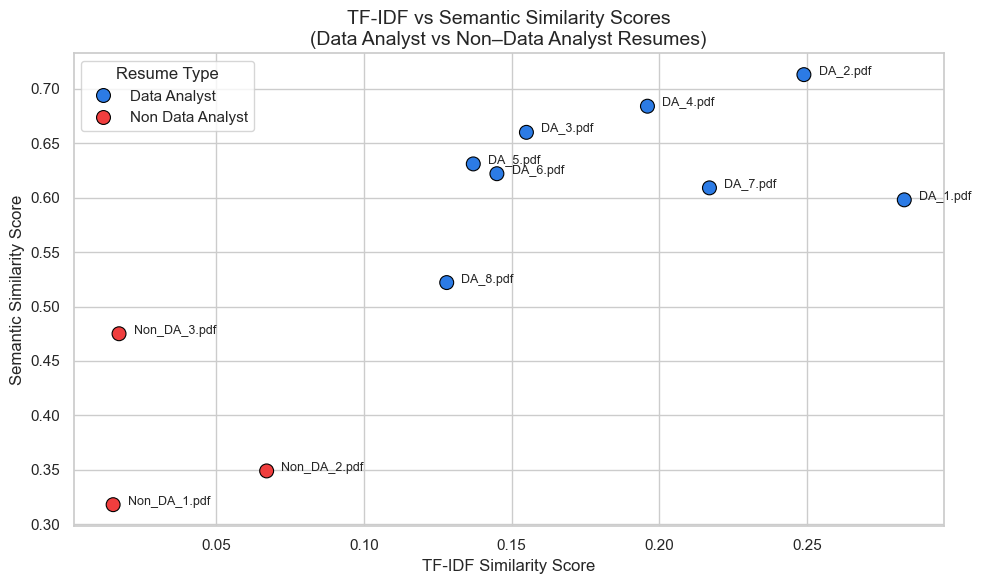

In [83]:
# Set style
sns.set(style="whitegrid")

# Create figure
plt.figure(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=score_table_v2,
    x="TF-IDF Score",
    y="Semantic Score",
    hue="Type",  
    s=100,
    palette={"Data Analyst": "#2c7be5", "Non Data Analyst": "#f03e3e"},
    edgecolor="black"
)

# Add labels
for i, row in score_table_v2.iterrows():
    plt.text(row["TF-IDF Score"] + 0.005, row["Semantic Score"], row["Resume"], fontsize=9)

plt.title("TF-IDF vs Semantic Similarity Scores\n(Data Analyst vs Non–Data Analyst Resumes)", fontsize=14)
plt.xlabel("TF-IDF Similarity Score")
plt.ylabel("Semantic Similarity Score")
plt.legend(title="Resume Type", loc="upper left")
plt.tight_layout()
plt.show()

*Rank Scatterplot*

In [94]:
# # Set style
# sns.set(style="whitegrid")

# # Create figure
# plt.figure(figsize=(10, 6))

# # Scatter plot
# sns.scatterplot(
#     data=score_table_v2,
#     x="TF-IDF Rank",
#     y="Semantic Rank",
#     hue="Type",  
#     s=100,
#     palette={"Data Analyst": "#2c7be5", "Non Data Analyst": "#f03e3e"},
#     edgecolor="black"
# )

# # Add labels
# for i, row in score_table_v2.iterrows():
#     plt.text(row["TF-IDF Rank"] + 0.005, row["Semantic Rank"], row["Resume"], fontsize=9)

# plt.title("TF-IDF vs Semantic Similarity Ranks\n(Data Analyst vs Non–Data Analyst Resumes)", fontsize=14)
# plt.xlabel("TF-IDF Similarity Rank")
# plt.ylabel("Semantic Similarity Rank")
# plt.legend(title="Resume Type", loc="upper left")
# plt.tight_layout()
# plt.show()

*Plotly Scatterplot*

In [90]:
# import plotly.express as px
# fig = px.scatter(score_table_v2, x='TF-IDF Rank', y='Semantic Rank',
#                  hover_name='Resume', color='Type',
#                 height=600, width=800)
# fig.show()

Model Agreement

- Both models **consistently ranked Data Analyst (DA) resumes higher** than Non–DA resumes even without label.
- The **top 8 ranks in both models** are entirely occupied by resumes tagged as Data Analyst.

Score Behavior

- **TF-IDF scores** are generally lower across all resumes because they focus on exact word matches.
- **Semantic scores** are comparatively higher, especially for resumes like `DA_2.pdf` and `DA_4.pdf` even if not exact keyword matches.

Plot-Level Insight

- The **scatter plot** helps visualize how both models behave:
  - Resumes that are strong in both models (top-right area in ranking terms) are clearly relevant.
  - Non–DA resumes cluster in the **bottom-left area** : low scores from both methods.
  - `DA_8.pdf` stands out slightly lower scores in both models. This is expected as it's a **Data Science Intern**, possibly lighter on direct DA terminology.


# Conclusion & Limitation

## Conclusion

- Both models; TF-IDF & Sentence Transformer show clear ability to differentiate unrelated resumes.
- The semantic model, in particular, captures contextual matches even when exact words differ, while TF-IDF ensures resumes include critical domain specific terms.
- Together, they form a strong foundation for an **automated resume filtering system**, helping remove candidates whose resumes align distant with the job description.

## Limitation

- **Choosing a threshold isn’t straightforward**: Semantic scores and TF-IDF scores are on different scales, and both may vary depending on how the JD is written.
- TF-IDF may penalize resumes that use different wording for the same skills. 
- Semantic models might still assign moderate scores to irrelevant resumes that contain general terms like `data`, `project`, or `skills`.

*(Experimental)*

In [96]:
# def classify_single_resume(pdf_path, jd_text_raw, 
#                            tfidf_threshold=0.10, semantic_threshold=0.5):
#     # Extract & preprocess resume text
#     raw_resume = extract_text_from_pdf(pdf_path)
#     clean_resume = preprocess_text(raw_resume)
#     jd_text_clean = preprocess_text(jd_text_raw)

#     # Calculate both scores
#     tfidf_score = calculate_tfidf_similarity(clean_resume, jd_text_clean)
#     semantic_score = calculate_semantic_similarity(raw_resume, jd_text_raw)

#     # Decision logic
#     if tfidf_score >= tfidf_threshold or semantic_score >= semantic_threshold:
#         label = "Relevant"
#     else:
#         label = "Not Relevant"

#     return {
#         "Resume File": os.path.basename(pdf_path),
#         "TF-IDF Score": round(tfidf_score, 3),
#         "Semantic Score": round(semantic_score, 3),
#         "Prediction": label
#     }


In [97]:
# cv_pdf = os.path.join(base_path,"Data Analyst - CVs", "Non_DA_1.pdf")
# result = classify_single_resume(cv_pdf, DA_JD_Text)
# display(result)

{'Resume File': 'Non_DA_1.pdf',
 'TF-IDF Score': np.float64(0.015),
 'Semantic Score': 0.318,
 'Prediction': 'Not Relevant'}